In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

df = pd.read_csv("queries/rt_distribution_table6.csv", thousands=",")
BINW = 0.5
FACT = "6 X 5"                       # tria el fet aquí

sub = df[df["operation"] == FACT].sort_values("rt_bin")
x = (sub["rt_bin"] + BINW / 2).values          # bin centres
n = sub["n"].values.astype(float)
dens = n / (n.sum() * BINW)                      # density

# mean and median from the binned counts
mean_rt = (x * n).sum() / n.sum()
cum = np.cumsum(n) / n.sum()
median_rt = x[np.searchsorted(cum, 0.5)]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(x, dens, color="#3573b9", lw=1.8, label=f"{FACT.replace(' X ', '\u00d7')}")
ax.fill_between(x, dens, color="#3573b9", alpha=0.12)

ax.axvline(median_rt, color="#2a9d5c", ls="--", lw=1.6,
           label=f"median = {median_rt:.1f} s")
ax.axvline(mean_rt, color="#b02418", ls="--", lw=1.6,
           label=f"mean = {mean_rt:.1f} s")

ax.set_xlabel("response time (s)")
ax.set_ylabel("probability density")
ax.set_title(f"First-attempt RT distribution \u2014 {FACT.replace(' X ', '\u00d7')} "
             f"(pooled over grades)", fontsize=12, pad=8)
ax.legend(frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("plots/rt_distribution_single_fact.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/rt_distribution_single_fact.pdf", bbox_inches="tight")
plt.show()

print(f"{FACT}:  median = {median_rt:.2f} s,  mean = {mean_rt:.2f} s,  "
      f"mean/median = {mean_rt/median_rt:.2f}")

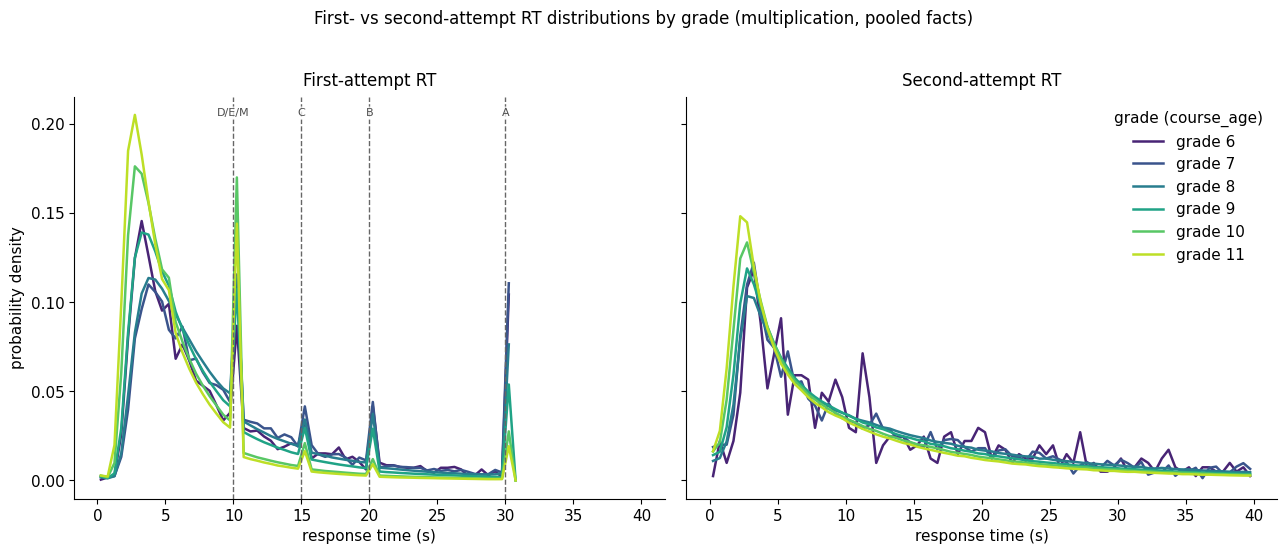

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from collections import defaultdict

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})
# columns: grade, attempt ('first'/'second'), rt_bin, n
df = pd.read_csv("queries/rt_distribution_by_grade.csv", thousands=",")
BINW = 0.5
MIN_N = 5000                       # drop grades with too little data to be a stable density
# keep grades with enough total attempts overall
tot = df.groupby("grade")["n"].sum()
grades = sorted(g for g in tot.index if tot[g] >= MIN_N)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(grades)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharex=True, sharey=True)
for ax, att, title in zip(axes, ["first", "second"],
                          ["First-attempt RT", "Second-attempt RT"]):
    for g, c in zip(grades, colors):
        sub = df[(df["attempt"] == att) & (df["grade"] == g)].sort_values("rt_bin")
        if sub["n"].sum() == 0:
            continue
        dens = sub["n"] / (sub["n"].sum() * BINW)          # normalize to a density
        x = sub["rt_bin"] + BINW / 2                       # bin centres
        ax.plot(x, dens, color=c, lw=1.8, label=f"grade {int(g)}")
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("response time (s)")
    # ax.set_xlim(0, 20)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# --- Leitner "time before help" markers, on the FIRST-attempt panel only ---
help_times = {"A": 30, "B": 20, "C": 15, "D": 10, "E": 10, "Memory": 10}
by_t = defaultdict(list)
for box, t in help_times.items():
    by_t[t].append(box)

ax0 = axes[0]
ymax = ax0.get_ylim()[1]
for t, boxes in by_t.items():
    ax0.axvline(t, color="0.4", ls="--", lw=1)
    ax0.text(t, ymax * 0.97, "/".join(b[0] for b in boxes),      # A, B, C, D/E/M
             ha="center", va="top", fontsize=8, color="0.3",
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

axes[0].set_ylabel("probability density")
axes[1].legend(title="grade (course_age)", frameon=False)
fig.suptitle("First- vs second-attempt RT distributions by grade "
             "(multiplication, pooled facts)", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig("plots/rt_distributions_by_grade.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/rt_distributions_by_grade.pdf", bbox_inches="tight")
plt.show()

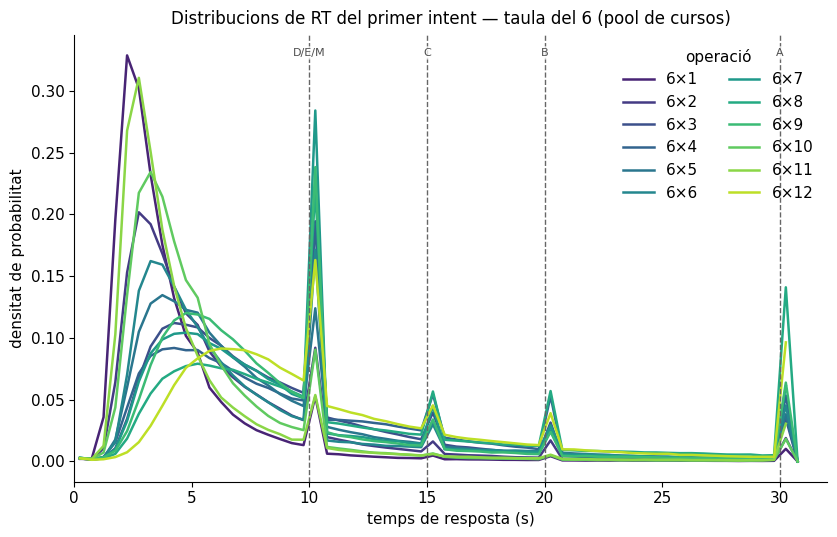

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from collections import defaultdict

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

# columns: operation ("6 X b"), rt_bin, n
df = pd.read_csv("queries/rt_distribution_table6.csv", thousands=",")
BINW = 0.5

# segon operand b, per ordenar i etiquetar
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
bs = sorted(df["b"].unique())
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(bs)))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for b, c in zip(bs, colors):
    sub = df[df["b"] == b].sort_values("rt_bin")
    if sub["n"].sum() == 0:
        continue
    dens = sub["n"] / (sub["n"].sum() * BINW)      # normalitzar a densitat
    x = sub["rt_bin"] + BINW / 2                    # centre del bin
    ax.plot(x, dens, color=c, lw=1.8, label=f"6\u00d7{b}")

ax.set_xlabel("temps de resposta (s)")
ax.set_ylabel("densitat de probabilitat")
ax.set_xlim(0, 32)                                  # ample perquè es vegi la línia A (30 s)
ax.set_title("Distribucions de RT del primer intent \u2014 taula del 6 (pool de cursos)",
             fontsize=12, pad=8)

# --- línies "temps abans d'ajuda" de Leitner ---
help_times = {"A": 30, "B": 20, "C": 15, "D": 10, "E": 10, "Memory": 10}
by_t = defaultdict(list)
for box, t in help_times.items():
    by_t[t].append(box)

ymax = ax.get_ylim()[1]
for t, boxes in by_t.items():
    ax.axvline(t, color="0.4", ls="--", lw=1)
    ax.text(t, ymax * 0.97, "/".join(b[0] for b in boxes),      # A, B, C, D/E/M
            ha="center", va="top", fontsize=8, color="0.3",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

ax.legend(title="operació", frameon=False, ncol=2)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("plots/rt_distributions_table6.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/rt_distributions_table6.pdf", bbox_inches="tight")
plt.show()

## Cleaning data spikes

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})

df = pd.read_csv("queries/rt_box_table6.csv", thousands=",")
BINW = 0.5
TIMEOUTS  = [10, 15, 20, 30]
SPIKE_WIN = 0.9
LAM       = 1.0
MIN_ROOM  = 2 * LAM          # need this much tail beyond a timeout to redistribute into it

df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
raw = df.groupby(["b", "rt_bin"], as_index=False)["n"].sum()

def spike_mask(x):
    m = np.zeros(len(x), dtype=bool)
    for T in TIMEOUTS:
        m |= (x >= T - 1e-9) & (x <= T + SPIKE_WIN)
    return m

def clean_fact(sub):
    sub = sub.sort_values("rt_bin")
    x = sub["rt_bin"].values + BINW / 2
    n = sub["n"].values.astype(float)
    N = n.sum()
    dens = n / (N * BINW)
    spike = spike_mask(x)
    spike[0] = False                              # keep first bin as anchor; do NOT force the last
    pch = PchipInterpolator(x[~spike], dens[~spike], extrapolate=True)
    base = np.clip(pch(x), 0, None)               # trailing edge spike is extrapolated through (decays)
    clean = base.copy()
    xmax = x.max()
    for T in TIMEOUTS:
        nb = (x >= T - 1e-9) & (x <= T + SPIKE_WIN)
        M = max(np.sum(dens[nb] - base[nb]) * BINW, 0.0)
        if M <= 0 or (xmax - T) < MIN_ROOM:       # no room beyond (e.g. 30 s): drop, keep smooth baseline
            continue
        ramp = np.where(x > T, 1 - np.exp(-((x - T) / LAM) ** 2), 0.0)
        shape = base * ramp
        area = np.sum(shape) * BINW
        if area > 0:
            clean += M * shape / area
    return sub["rt_bin"].values, dens, clean, N

bs = sorted(raw["b"].unique())
fig, axes = plt.subplots(4, 3, figsize=(14, 15))
clean_rows = []
for ax, b in zip(axes.flat, bs):
    rt_bin, dens, clean, N = clean_fact(raw[raw["b"] == b])
    x = rt_bin + BINW / 2
    ax.plot(x, dens,  color="0.6",     lw=1.3, label="original")
    ax.plot(x, clean, color="#b02418", lw=1.8, label="cleaned")
    ax.set_title(f"6\u00d7{b}", fontsize=9)
    ax.grid(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    clean_rows.append(pd.DataFrame({"operation": f"6 X {b}", "rt_bin": rt_bin,
                                    "n": clean * BINW * N}))
axes.flat[0].legend(fontsize=8, frameon=False)
fig.supxlabel("response time (s)"); fig.supylabel("probability density")
fig.suptitle("Original vs cleaned RT (C1 baseline + smooth-ramp redistribution) \u2014 6\u00d7 table", y=1.005)
fig.tight_layout()
fig.savefig("plots/rt_cleaned_table6.png", dpi=300, bbox_inches="tight")
plt.show()

df_clean = pd.concat(clean_rows, ignore_index=True)[["operation", "rt_bin", "n"]]
Path("cache").mkdir(exist_ok=True)
df_clean.to_parquet("cache/rt_distribution_table6_clean.parquet", index=False)  # in-notebook checkpoint, not a warehouse pull -- see README

## Log-normal test

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statistics import NormalDist
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})
nd = NormalDist()

T0_GRID = np.linspace(0.0, 2.0, 201)          # search shift between 0 and 2 s

df = pd.read_parquet("cache/rt_distribution_table6_clean.parquet")   # cleaned file; swap if you want raw
BINW = 0.5
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)

def qq(x, w, t0):
    keep = x > t0
    if keep.sum() < 5:
        return None
    u = np.log(x[keep] - t0)
    ww = w[keep]
    cum = (np.cumsum(ww) - 0.5 * ww) / ww.sum()
    z = np.array([nd.inv_cdf(p) for p in cum])
    return z, u

def best_t0(x, w):
    best, best_ppcc = 0.0, -np.inf
    for t0 in T0_GRID:
        r = qq(x, w, t0)
        if r is None:
            continue
        z, u = r
        ppcc = np.corrcoef(z, u)[0, 1]
        if ppcc > best_ppcc:
            best_ppcc, best = ppcc, t0
    return best, best_ppcc

bs = sorted(df["b"].unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, b in zip(axes.flat, bs):
    sub = df[df["b"] == b].sort_values("rt_bin")
    x = sub["rt_bin"].values + BINW / 2
    w = sub["n"].values.astype(float)
    t0, ppcc = best_t0(x, w)
    z, u = qq(x, w, t0)
    sl, ic = np.polyfit(z, u, 1)
    ax.scatter(z, u, s=8, color="#3573b9", alpha=0.6)
    ax.plot(z, ic + sl * z, color="#b02418", lw=1.5)
    ax.set_title(f"6\u00d7{b}   t\u2080={t0:.2f}s   PPCC={ppcc:.4f}", fontsize=10)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

fig.supxlabel("theoretical normal quantiles")
fig.supylabel("ln(RT \u2212 t\u2080) sample quantiles")
fig.suptitle("Q\u2013Q plots of ln(RT \u2212 t\u2080) vs normal, t\u2080 chosen to maximize PPCC (0\u20132 s) \u2014 6\u00d7 table",
             y=1.005)
fig.tight_layout()
fig.savefig("plots/logrt_bestshift_qq_table6.png", dpi=300, bbox_inches="tight")
plt.show()

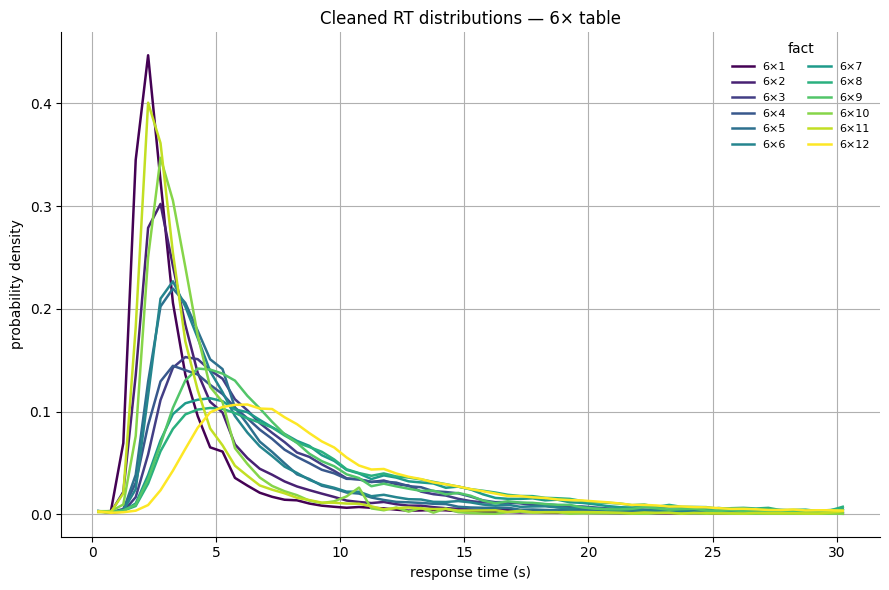

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(bs)))

for b, c in zip(bs, colors):
    rt_bin, dens, clean, N = clean_fact(raw[raw["b"] == b])
    x = rt_bin + BINW / 2
    ax.plot(x, clean, color=c, lw=1.8, label=f"6\u00d7{b}")

ax.grid(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_xlabel("response time (s)")
ax.set_ylabel("probability density")
ax.set_title("Cleaned RT distributions \u2014 6\u00d7 table")
ax.legend(fontsize=8, frameon=False, ncol=2, title="fact")
fig.tight_layout()
plt.show()

## Fitting lognorm parameters 

$\ln(RT−t_0​)\sim N(\mu,s^2)$

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import minimize
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})

df = pd.read_parquet("cache/rt_distribution_table6_grade11_clean.parquet")
BINW  = 0.5
FACTS = [3, 4, 7, 8, 9, 12]
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
df = df[df["rt_bin"] > 0]                      # ln needs RT > 0

# ---- binned negative log-likelihood for a shifted lognormal ----
def nll(theta, e_lo, e_hi, n):
    t0, mu, s = theta
    if s <= 1e-4 or t0 < 0:
        return np.inf
    p = (lognorm.cdf(e_hi, s, loc=t0, scale=np.exp(mu)) -
         lognorm.cdf(e_lo, s, loc=t0, scale=np.exp(mu)))
    p = np.clip(p, 1e-300, None)
    return -np.sum(n * np.log(p))

# ---- numerical Hessian (central differences) for standard errors ----
def num_hessian(f, x, rel=1e-3, abs_=1e-4):
    x = np.asarray(x, float); m = x.size
    h = rel*np.abs(x) + abs_; H = np.zeros((m, m))
    for i in range(m):
        for j in range(i, m):
            xpp, xpm, xmp, xmm = (x.copy() for _ in range(4))
            xpp[i]+=h[i]; xpp[j]+=h[j]
            xpm[i]+=h[i]; xpm[j]-=h[j]
            xmp[i]-=h[i]; xmp[j]+=h[j]
            xmm[i]-=h[i]; xmm[j]-=h[j]
            H[i, j] = H[j, i] = (f(xpp)-f(xpm)-f(xmp)+f(xmm))/(4*h[i]*h[j])
    return H

def fit_fact(sub):
    sub  = sub.sort_values("rt_bin")
    e_lo = sub["rt_bin"].values
    e_hi = e_lo + BINW
    n    = sub["n"].values.astype(float)
    keep = n > 0
    e_lo, e_hi, n = e_lo[keep], e_hi[keep], n[keep]
    ctr  = (e_lo + e_hi) / 2

    # method-of-moments start, with t0 below the first bin
    t0_0 = 0.5 * e_lo.min()
    u0   = np.log(ctr - t0_0)
    mu_0 = np.average(u0, weights=n)
    s_0  = np.sqrt(np.average((u0 - mu_0)**2, weights=n))
    x0   = [t0_0, mu_0, s_0]

    res  = minimize(nll, x0, args=(e_lo, e_hi, n), method="Nelder-Mead",
                    options=dict(xatol=1e-6, fatol=1e-8, maxiter=20000))
    t0, mu, s = res.x

    # standard errors from inverse observed-information
    H   = num_hessian(lambda th: nll(th, e_lo, e_hi, n), res.x)
    try:
        cov = np.linalg.inv(H); se = np.sqrt(np.diag(cov))
    except np.linalg.LinAlgError:
        se = np.full(3, np.nan)
    se_t0, se_mu, se_s = se

    # R^2 in RT-density space (diagnostic only)
    dens = (n / n.sum()) / BINW
    pred = lognorm.pdf(ctr, s, loc=t0, scale=np.exp(mu))
    r2   = 1 - np.sum((dens-pred)**2) / np.sum((dens-dens.mean())**2)
    return dict(e_lo=e_lo, e_hi=e_hi, n=n, ctr=ctr, dens=dens,
                t0=t0, mu=mu, s=s, se_t0=se_t0, se_mu=se_mu, se_s=se_s, r2=r2)

# ---- fit, print, plot ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
rows = []
for ax, b in zip(axes.flat, FACTS):
    f = fit_fact(df[df["b"] == b])
    rows.append((b, f["t0"], f["mu"], f["se_mu"], f["s"], f["se_s"], f["r2"]))

    print(f"6x{b:<2}  t0 = {f['t0']:.3f} s        "
          f"mu = {f['mu']:.3f} +/- {f['se_mu']:.3f}   "
          f"s = {f['s']:.3f} +/- {f['se_s']:.3f}   (R2={f['r2']:.3f})")

    xg  = np.linspace(f["t0"] + 1e-3, f["e_hi"].max(), 400)
    pdf = lognorm.pdf(xg, f["s"], loc=f["t0"], scale=np.exp(f["mu"]))
    ax.scatter(f["ctr"], f["dens"], s=20, color="#3573b9", alpha=0.6, label="data")
    ax.plot(xg, pdf, color="#b02418", lw=1.8, label="lognormal fit")
    ax.set_title(f"6\u00d7{b}   R\u00b2={f['r2']:.3f}", fontsize=10)
    ax.text(0.96, 0.80,
            f"$t_0$={f['t0']:.2f}\n$\\mu$={f['mu']:.2f}$\\pm${f['se_mu']:.2f}"
            f"\n$s$={f['s']:.2f}$\\pm${f['se_s']:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
axes.flat[0].legend(fontsize=8, frameon=False)
fig.supxlabel("response time (s)"); fig.supylabel("probability density")
fig.suptitle("Shifted-lognormal fits  ln(RT\u2212t\u2080)~N(\u03bc,s\u00b2) \u2014 6\u00d7 table, grade 11", y=1.02)
fig.tight_layout()
fig.savefig("plots/lognorm_shift_fits_table6_grade11.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- check the s's are similar ----
summ = pd.DataFrame(rows, columns=["fact", "t0", "mu", "se_mu", "s", "se_s", "r2"])
print("\n", summ.to_string(index=False,
      formatters={c: "{:.3f}".format for c in ["t0","mu","se_mu","s","se_s","r2"]}))
print(f"\ns:  mean={summ['s'].mean():.3f}  sd={summ['s'].std(ddof=1):.3f}  "
      f"CV={summ['s'].std(ddof=1)/summ['s'].mean():.1%}   "
      f"range=[{summ['s'].min():.3f}, {summ['s'].max():.3f}]")

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import minimize
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})

df = pd.read_parquet("cache/rt_distribution_table6_grade11_clean.parquet")
BINW  = 0.5
FACTS = [3, 4, 7, 8, 9, 12]
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
df = df[df["rt_bin"] > 0]

def unpack(th):                       # transforms keep params in valid ranges
    t0  = th[0]
    mu1, mu2 = th[1], th[2]
    s1, s2   = np.exp(th[3]), np.exp(th[4])
    pi  = 1 / (1 + np.exp(-th[5]))
    return t0, mu1, mu2, s1, s2, pi

def cdf_mix(x, th):
    t0, mu1, mu2, s1, s2, pi = unpack(th)
    return (pi     * lognorm.cdf(x, s1, loc=t0, scale=np.exp(mu1)) +
            (1-pi) * lognorm.cdf(x, s2, loc=t0, scale=np.exp(mu2)))

def nll(th, e_lo, e_hi, n):
    if th[0] < 0:
        return np.inf
    p = cdf_mix(e_hi, th) - cdf_mix(e_lo, th)
    return -np.sum(n * np.log(np.clip(p, 1e-300, None)))

def fit_mix(sub):
    sub  = sub.sort_values("rt_bin")
    e_lo = sub["rt_bin"].values; e_hi = e_lo + BINW
    n    = sub["n"].values.astype(float)
    keep = n > 0
    e_lo, e_hi, n = e_lo[keep], e_hi[keep], n[keep]
    ctr  = (e_lo + e_hi) / 2

    t0_0 = 0.5 * e_lo.min()
    mu0  = np.average(np.log(ctr - t0_0), weights=n)
    inits = [                                             # a few restarts
        [t0_0, mu0-0.2, mu0+0.6, np.log(0.35), np.log(0.7), 1.0],
        [t0_0, mu0,     mu0+0.9, np.log(0.30), np.log(0.6), 0.5],
        [t0_0, mu0-0.3, mu0+0.4, np.log(0.40), np.log(0.8), 1.5],
    ]
    best = None
    for x0 in inits:
        r = minimize(nll, x0, args=(e_lo, e_hi, n), method="Nelder-Mead",
                     options=dict(xatol=1e-7, fatol=1e-9, maxiter=60000))
        if best is None or r.fun < best.fun:
            best = r
    t0, mu1, mu2, s1, s2, pi = unpack(best.x)
    if s1 > s2:                                           # comp 1 = sharp/retrieval
        mu1, mu2, s1, s2, pi = mu2, mu1, s2, s1, 1 - pi

    dens = (n / n.sum()) / BINW
    pred = (pi     * lognorm.pdf(ctr, s1, loc=t0, scale=np.exp(mu1)) +
            (1-pi) * lognorm.pdf(ctr, s2, loc=t0, scale=np.exp(mu2)))
    r2   = 1 - np.sum((dens-pred)**2) / np.sum((dens-dens.mean())**2)
    return dict(e_hi=e_hi, ctr=ctr, dens=dens, t0=t0,
                mu1=mu1, s1=s1, mu2=mu2, s2=s2, pi=pi, r2=r2)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
rows = []
for ax, b in zip(axes.flat, FACTS):
    f = fit_mix(df[df["b"] == b])
    rows.append((b, f["t0"], f["mu1"], f["s1"], f["pi"], f["mu2"], f["s2"], f["r2"]))
    print(f"6x{b:<2}  t0={f['t0']:.3f}  |  retrieval: mu1={f['mu1']:.3f} s1={f['s1']:.3f} "
          f"pi={f['pi']:.2f}  |  slow: mu2={f['mu2']:.3f} s2={f['s2']:.3f}  (R2={f['r2']:.4f})")

    xg  = np.linspace(f["t0"] + 1e-3, f["e_hi"].max(), 500)
    c1  = f["pi"]     * lognorm.pdf(xg, f["s1"], loc=f["t0"], scale=np.exp(f["mu1"]))
    c2  = (1-f["pi"]) * lognorm.pdf(xg, f["s2"], loc=f["t0"], scale=np.exp(f["mu2"]))
    ax.scatter(f["ctr"], f["dens"], s=18, color="#3573b9", alpha=0.6, label="data")
    ax.plot(xg, c1+c2, color="#b02418", lw=1.8, label="mixture")
    ax.plot(xg, c1, color="#1a7f37", lw=1.2, ls="--", label="retrieval")
    ax.plot(xg, c2, color="0.5",     lw=1.2, ls="--", label="slow")
    ax.set_title(f"6\u00d7{b}   R\u00b2={f['r2']:.4f}", fontsize=10)
    ax.text(0.96, 0.80,
            f"$t_0$={f['t0']:.2f}\n$\\mu_1$={f['mu1']:.2f}  $s_1$={f['s1']:.2f}"
            f"\n$\\pi$={f['pi']:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
axes.flat[0].legend(fontsize=8, frameon=False)
fig.supxlabel("response time (s)"); fig.supylabel("probability density")
fig.suptitle("Two-component shifted-lognormal fits \u2014 6\u00d7 table, grade 11", y=1.02)
fig.tight_layout()
fig.savefig("plots/lognorm_mix_fits_table6_grade11.png", dpi=300, bbox_inches="tight")
plt.show()

summ = pd.DataFrame(rows, columns=["fact","t0","mu1","s1","pi","mu2","s2","r2"])
print("\n", summ.to_string(index=False,
      formatters={c: "{:.3f}".format for c in ["t0","mu1","s1","pi","mu2","s2","r2"]}))
print(f"\nretrieval s1:  mean={summ['s1'].mean():.3f}  "
      f"CV={summ['s1'].std(ddof=1)/summ['s1'].mean():.1%}   "
      f"range=[{summ['s1'].min():.3f}, {summ['s1'].max():.3f}]")

## 11-grade filter
### Do older students rely more heavily on retrieval?

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})

df = pd.read_csv("queries/rt_box_table6_grade11.csv", thousands=",")
BINW = 0.5
TIMEOUTS  = [10, 15, 20, 30]
SPIKE_WIN = 0.9
LAM       = 1.0
MIN_ROOM  = 2 * LAM

df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
raw = df.groupby(["b", "rt_bin"], as_index=False)["n"].sum()

def spike_mask(x):
    m = np.zeros(len(x), dtype=bool)
    for T in TIMEOUTS:
        m |= (x >= T - 1e-9) & (x <= T + SPIKE_WIN)
    return m

def clean_fact(sub):
    sub = sub.sort_values("rt_bin")
    x = sub["rt_bin"].values + BINW / 2
    n = sub["n"].values.astype(float)
    N = n.sum()
    dens = n / (N * BINW)
    spike = spike_mask(x)
    spike[0] = False
    pch = PchipInterpolator(x[~spike], dens[~spike], extrapolate=True)
    base = np.clip(pch(x), 0, None)
    clean = base.copy()
    xmax = x.max()
    for T in TIMEOUTS:
        nb = (x >= T - 1e-9) & (x <= T + SPIKE_WIN)
        M = max(np.sum(dens[nb] - base[nb]) * BINW, 0.0)
        if M <= 0 or (xmax - T) < MIN_ROOM:
            continue
        ramp = np.where(x > T, 1 - np.exp(-((x - T) / LAM) ** 2), 0.0)
        shape = base * ramp
        area = np.sum(shape) * BINW
        if area > 0:
            clean += M * shape / area
    return sub["rt_bin"].values, dens, clean, N

bs = sorted(raw["b"].unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
clean_rows = []
for ax, b in zip(axes.flat, bs):
    rt_bin, dens, clean, N = clean_fact(raw[raw["b"] == b])
    x = rt_bin + BINW / 2
    ax.plot(x, dens,  color="0.6",     lw=1.3, label="original")
    ax.plot(x, clean, color="#b02418", lw=1.8, label="cleaned")
    ax.set_title(f"6\u00d7{b}", fontsize=9)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    clean_rows.append(pd.DataFrame({"operation": f"6 X {b}", "rt_bin": rt_bin,
                                    "n": clean * BINW * N}))
axes.flat[0].legend(fontsize=8, frameon=False)
fig.supxlabel("response time (s)"); fig.supylabel("probability density")
fig.suptitle("Original vs cleaned RT \u2014 6\u00d7 table, grade 11", y=1.005)
fig.tight_layout()
fig.savefig("plots/rt_cleaned_table6_grade11.png", dpi=300, bbox_inches="tight")
plt.show()

df_clean = pd.concat(clean_rows, ignore_index=True)[["operation", "rt_bin", "n"]]
Path("cache").mkdir(exist_ok=True)
df_clean.to_parquet("cache/rt_distribution_table6_grade11_clean.parquet", index=False)  # in-notebook checkpoint, not a warehouse pull -- see README

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})

df = pd.read_parquet("cache/rt_distribution_table6_grade11_clean.parquet")
BINW = 0.5
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
df = df[df["rt_bin"] > 0]                                   # ln needs RT > 0

def parabola(sub):
    sub = sub.sort_values("rt_bin")
    e_lo = sub["rt_bin"].values; e_hi = e_lo + BINW
    u  = (np.log(e_lo) + np.log(e_hi)) / 2          # ln(RT) bin centre
    du = np.log(e_hi) - np.log(e_lo)                # log bin width (Jacobian)
    n  = sub["n"].values.astype(float)
    dens = (n / n.sum()) / du                        # density of ln(RT)
    keep = n >= 50                                   # avoid log-of-noise in thin bins
    u, dens, w = u[keep], dens[keep], n[keep]
    y  = np.log(dens)
    mu = np.average(u, weights=w)
    z  = (u - mu) ** 2                               # squared deviation
    slope, a = np.polyfit(z, y, 1, w=np.sqrt(w))     # weighted linear fit y = a + slope*z
    yhat = a + slope * z
    r2 = 1 - np.sum(w*(y-yhat)**2) / np.sum(w*(y-np.average(y, weights=w))**2)
    sigma = np.sqrt(-1/(2*slope)) if slope < 0 else np.nan
    return u, y, mu, slope, a, r2, sigma

bs = sorted(df["b"].unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, b in zip(axes.flat, bs):
    u, y, mu, slope, a, r2, sigma = parabola(df[df["b"] == b])
    ug = np.linspace(u.min(), u.max(), 200)
    ax.scatter(u, y, s=20, color="#3573b9", alpha=0.6)
    ax.plot(ug, a + slope*(ug-mu)**2, color="#b02418", lw=1.8)      # fitted parabola
    ax.set_title(f"6\u00d7{b}   R\u00b2={r2:.3f}", fontsize=10)
    ax.set_xticks(np.log([2, 5, 10, 20])); ax.set_xticklabels([2, 5, 10, 20])
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    print(f"6x{b:<2}  parabola R\u00b2={r2:.3f}   sigma(log)={sigma:.2f}")

fig.supxlabel("response time (s, log scale)"); fig.supylabel("ln(density)")
fig.suptitle("Log-density vs fitted Gaussian parabola \u2014 6\u00d7 table, grade 11 (cleaned)", y=1.005)
fig.tight_layout()
fig.savefig("plots/logrt_parabola_fits_table6_grade11_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statistics import NormalDist
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "font.size": 10})
nd = NormalDist()

T0_GRID = np.linspace(0.0, 2.0, 201)

df = pd.read_parquet("cache/rt_distribution_table6_grade11_clean.parquet")
BINW = 0.5
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)

def qq(x, w, t0):
    keep = x > t0
    if keep.sum() < 5:
        return None
    u = np.log(x[keep] - t0)
    ww = w[keep]
    cum = (np.cumsum(ww) - 0.5 * ww) / ww.sum()
    z = np.array([nd.inv_cdf(p) for p in cum])
    return z, u

def best_t0(x, w):
    best, best_ppcc = 0.0, -np.inf
    for t0 in T0_GRID:
        r = qq(x, w, t0)
        if r is None:
            continue
        z, u = r
        ppcc = np.corrcoef(z, u)[0, 1]
        if ppcc > best_ppcc:
            best_ppcc, best = ppcc, t0
    return best, best_ppcc

bs = sorted(df["b"].unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, b in zip(axes.flat, bs):
    sub = df[df["b"] == b].sort_values("rt_bin")
    x = sub["rt_bin"].values + BINW / 2
    w = sub["n"].values.astype(float)
    t0, ppcc = best_t0(x, w)
    z, u = qq(x, w, t0)
    sl, ic = np.polyfit(z, u, 1)
    ax.scatter(z, u, s=8, color="#3573b9", alpha=0.6)
    ax.plot(z, ic + sl * z, color="#b02418", lw=1.5)
    ax.set_title(f"6\u00d7{b}   t\u2080={t0:.2f}s   PPCC={ppcc:.4f}", fontsize=10)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

fig.supxlabel("theoretical normal quantiles")
fig.supylabel("ln(RT \u2212 t\u2080) sample quantiles")
fig.suptitle("Q\u2013Q of ln(RT \u2212 t\u2080) vs normal, t\u2080 maximizing PPCC \u2014 6\u00d7 table, grade 11", y=1.005)
fig.tight_layout()
fig.savefig("plots/logrt_bestshift_qq_table6_grade11.png", dpi=300, bbox_inches="tight")
plt.show()

## Evolution of PPCC over the age

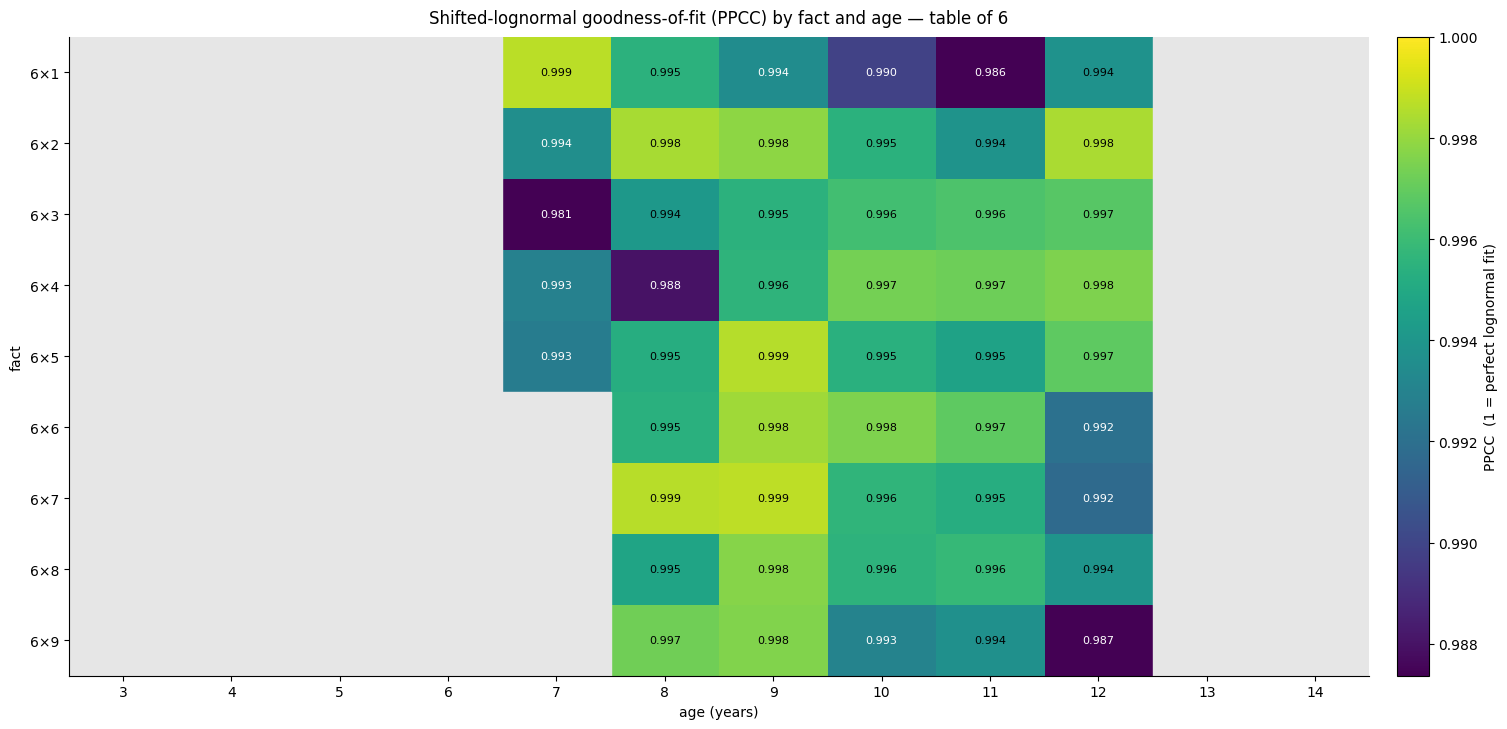

In [9]:
"""
PPCC heatmap for the table of 6: goodness-of-fit of the shifted-lognormal RT model
as a function of FACT (6x1 ... 6x9) and student AGE.

Input : queries/rt_distribution_table6_by_age.csv   (columns: operation, age, rt_bin, n)
Output: plots/ppcc_heatmap_table6_by_age.png / .pdf

PPCC = Probability Plot Correlation Coefficient: the correlation between the ordered
sample quantiles ln(RT - t0) and the theoretical normal quantiles in the Q-Q plot.
Reuses the exact qq() / best_t0() logic from rt_distribution.ipynb (cell 4).
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statistics import NormalDist
from matplotlib import rcParams
rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 10})
nd = NormalDist()

BINW    = 0.5
T0_GRID = np.linspace(0.0, 2.0, 201)   # search onset t0 in [0, 2] s, as in the notebook
MIN_N   = 200                          # min attempts in a (fact, age) cell to trust the PPCC
MIN_PTS = 5                            # min non-empty bins for a Q-Q fit

# ---- PPCC machinery (identical to rt_distribution.ipynb) --------------------
def qq(x, w, t0):
    keep = x > t0
    if keep.sum() < MIN_PTS:
        return None
    u  = np.log(x[keep] - t0)
    ww = w[keep]
    cum = (np.cumsum(ww) - 0.5 * ww) / ww.sum()
    z = np.array([nd.inv_cdf(p) for p in cum])
    return z, u

def best_t0(x, w):
    best, best_ppcc = np.nan, -np.inf
    for t0 in T0_GRID:
        r = qq(x, w, t0)
        if r is None:
            continue
        z, u = r
        ppcc = np.corrcoef(z, u)[0, 1]
        if ppcc > best_ppcc:
            best_ppcc, best = ppcc, t0
    return best, best_ppcc

def cell_ppcc(sub):
    """sub: rows for one (fact, age) cell with columns rt_bin, n."""
    sub = sub.sort_values("rt_bin")
    x = sub["rt_bin"].values + BINW / 2          # bin centres
    w = sub["n"].values.astype(float)
    if w.sum() < MIN_N:
        return np.nan, np.nan, w.sum()
    t0, ppcc = best_t0(x, w)
    return ppcc, t0, w.sum()

# ---- load children ----------------------------------------------------------
df = pd.read_csv("queries/rt_distribution_table6_by_age.csv", thousands=",")
df["b"] = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)

facts = list(range(1, 10))                       # 6x1 .. 6x9
ages  = sorted(df["age"].unique())

P = np.full((len(facts), len(ages)), np.nan)     # PPCC
T = np.full((len(facts), len(ages)), np.nan)     # chosen t0
N = np.zeros((len(facts), len(ages)))            # sample size
for i, b in enumerate(facts):
    for j, a in enumerate(ages):
        sub = df[(df["b"] == b) & (df["age"] == a)]
        if len(sub):
            P[i, j], T[i, j], N[i, j] = cell_ppcc(sub)

# ---- OPTIONAL: adult sample as an extra column ------------------------------
# Point this at your adult file. Expected columns: operation, rt_bin, n
# (age is irrelevant for adults -> single column labelled "adult").
ADULT_CSV = "queries/rt_distribution_table6_adult.csv"
adult_col = None
try:
    ad = pd.read_csv(ADULT_CSV, thousands=",")
    ad["b"] = ad["operation"].str.split(r"\s*X\s*", regex=True, expand=True)[1].astype(int)
    adult_col = np.full(len(facts), np.nan)
    for i, b in enumerate(facts):
        pp, _, _ = cell_ppcc(ad[ad["b"] == b])
        adult_col[i] = pp
except FileNotFoundError:
    pass

# assemble matrix + column labels
M = P.copy()
col_labels = [str(a) for a in ages]
if adult_col is not None:
    M = np.column_stack([M, adult_col])
    col_labels = col_labels + ["adult"]

# ---- plot -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(1.1 * M.shape[1] + 2, 0.6 * len(facts) + 2))
vmin = np.nanpercentile(M, 5)                    # stretch colours over the useful range
im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=vmin, vmax=1.0)

ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(col_labels)
ax.set_yticks(range(len(facts))); ax.set_yticklabels([f"6×{b}" for b in facts])
ax.set_xlabel("age (years)")
ax.set_ylabel("fact")
ax.set_title("Shifted-lognormal goodness-of-fit (PPCC) by fact and age — table of 6",
             fontsize=12, pad=10)

# annotate each cell; grey out cells with too little data (already NaN)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if np.isnan(v):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="0.9"))
            continue
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v < (vmin + 1) / 2 else "black", fontsize=8)
if adult_col is not None:                        # separator before the adult column
    ax.axvline(len(ages) - .5, color="black", lw=1.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("PPCC  (1 = perfect lognormal fit)")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("plots/ppcc_heatmap_table6_by_age.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/ppcc_heatmap_table6_by_age.pdf", bbox_inches="tight")
plt.show()

## Activation by fact